##Hotel Cancellations

A significant number of hotel bookings are called off due to cancellations or no-shows. The typical reasons for cancellations include change of plans, scheduling conflicts, etc. This is often made easier by the option to do so free of charge or preferably at a low cost which is beneficial to hotel guests but it is a less desirable and possibly revenue-diminishing factor for hotels to deal with. Such losses are particularly high on last-minute cancellations.

The new technologies involving online booking channels have dramatically changed customers’ booking possibilities and behavior. This adds a further dimension to the challenge of how hotels handle cancellations, which are no longer limited to traditional booking and guest characteristics.

The cancellation of bookings impact a hotel on various fronts:

Loss of resources (revenue) when the hotel cannot resell the room.
Additional costs of distribution channels by increasing commissions or paying for publicity to help sell these rooms.
Lowering prices last minute, so the hotel can resell a room, resulting in reducing the profit margin.
Human resources to make arrangements for the guests.
Objective

The increasing number of cancellations calls for a Machine Learning based solution that can help in predicting which booking is likely to be canceled. INN Hotels Group has a chain of hotels in Portugal, they are facing problems with the high number of booking cancellations and have reached out to your firm for data-driven solutions. You as a data scientist have to analyze the data provided to find which factors have a high influence on booking cancellations, build a predictive model that can predict which booking is going to be canceled in advance, and help in formulating profitable policies for cancellations and refunds.


## Data Dictionary

- **Booking_ID**: unique identifier of each booking
- **no_of_adults**: Number of adults
- **no_of_children**: Number of Children
- **no_of_weekend_nights**: Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel
- **no_of_week_nights**: Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel
- **type_of_meal_plan**: Type of meal plan booked by the customer:
     - Not Selected – No meal plan selected
     - Meal Plan 1 – Breakfast
     - Meal Plan 2 – Half board (breakfast and one other meal)
     - Meal Plan 3 – Full board (breakfast, lunch, and dinner)

- **required_car_parking_space**: Does the customer require a car parking space? (0 - No, 1- Yes)
- **room_type_reserved**: Type of room reserved by the customer. The values are ciphered (encoded) by INN Hotels.
- **lead_time**: Number of days between the date of booking and the arrival date
- **arrival_year**: Year of arrival date
- **arrival_month**: Month of arrival date
- **arrival_date**: Date of the month
- **market_segment_type**: Market segment designation.
repeated_guest: Is the customer a repeated guest? (0 - No, 1- Yes)
- **no_of_previous_cancellations**: Number of previous bookings that were canceled by the customer prior to the current booking
- **no_of_previous_bookings_not_canceled**: Number of previous bookings not canceled by the customer prior to the current booking
- **avg_price_per_room**: Average price per day of the reservation; prices of the rooms are dynamic. (in euros)
- **no_of_special_requests**: Total number of special requests made by the customer (e.g. high floor, view from the room, etc)
- **booking_status**: Flag indicating if the booking was canceled or not.

In [3]:
#import the important packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#KNN libraries
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

#Naive Bayes libraries
from sklearn.naive_bayes import GaussianNB

#Support Vector Machine libraries
from sklearn import svm

import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mariyamalshatta/inn-hotels-group")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'inn-hotels-group' dataset.
Path to dataset files: /kaggle/input/inn-hotels-group


In [5]:
# Install if needed
!pip install -q kagglehub

import pandas as pd
from pathlib import Path

# Download the dataset
dataset_directory = Path(
    kagglehub.dataset_download(
        "mariyamalshatta/inn-hotels-group"
    )
)

print("Dataset directory:", dataset_directory)

# Find every CSV in the downloaded directory
csv_files = list(dataset_directory.rglob("*.csv"))

print("\nCSV files found:")
for file in csv_files:
    print(file)

Using Colab cache for faster access to the 'inn-hotels-group' dataset.
Dataset directory: /kaggle/input/inn-hotels-group

CSV files found:
/kaggle/input/inn-hotels-group/INNHotelsGroup.csv


In [6]:
csv_path = dataset_directory / "INNHotelsGroup.csv"

# Fallback in case the file is inside a subdirectory
if not csv_path.exists():
    matches = [
        file for file in csv_files
        if file.name.lower() == "INNHotelsGroup.csv"
    ]

    if not matches:
        raise FileNotFoundError(
            f"INNHotelsGroup.csv was not found. Available files: {csv_files}"
        )

    csv_path = matches[0]

print("Loading:", csv_path)

INN_data = pd.read_csv(csv_path)

display(INN_data.head())

Loading: /kaggle/input/inn-hotels-group/INNHotelsGroup.csv


,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


##Exploring the database

In [7]:
INN_data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_adults,36275.0,1.844962,0.518715,0.0,2.0,2.00,2.0,4.0
no_of_children,36275.0,0.105279,0.402648,0.0,0.0,0.00,0.0,10.0
no_of_weekend_nights,36275.0,0.810724,0.870644,0.0,0.0,1.00,2.0,7.0
no_of_week_nights,36275.0,2.204300,1.410905,0.0,1.0,2.00,3.0,17.0
required_car_parking_space,36275.0,0.030986,0.173281,0.0,0.0,0.00,0.0,1.0
lead_time,36275.0,85.232557,85.930817,0.0,17.0,57.00,126.0,443.0
arrival_year,36275.0,2017.820427,0.383836,2017.0,2018.0,2018.00,2018.0,2018.0
arrival_month,36275.0,7.423653,3.069894,1.0,5.0,8.00,10.0,12.0
arrival_date,36275.0,15.596995,8.740447,1.0,8.0,16.00,23.0,31.0
repeated_guest,36275.0,0.025637,0.158053,0.0,0.0,0.00,0.0,1.0


In [8]:
INN_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [9]:
INN_data.shape

(36275, 19)

In [10]:
INN_data['type_of_meal_plan'].unique()

array(['Meal Plan 1', 'Not Selected', 'Meal Plan 2', 'Meal Plan 3'],
      dtype=object)

In [11]:
INN_data['market_segment_type'].unique()

array(['Offline', 'Online', 'Corporate', 'Aviation', 'Complementary'],
      dtype=object)

In [12]:
INN_data['room_type_reserved'].unique()

array(['Room_Type 1', 'Room_Type 4', 'Room_Type 2', 'Room_Type 6',
       'Room_Type 5', 'Room_Type 7', 'Room_Type 3'], dtype=object)

In [13]:
INN_data.isnull().sum()

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


In [14]:
INN_data.duplicated().sum()

np.int64(0)

##EDA

Busiest months in the hotel


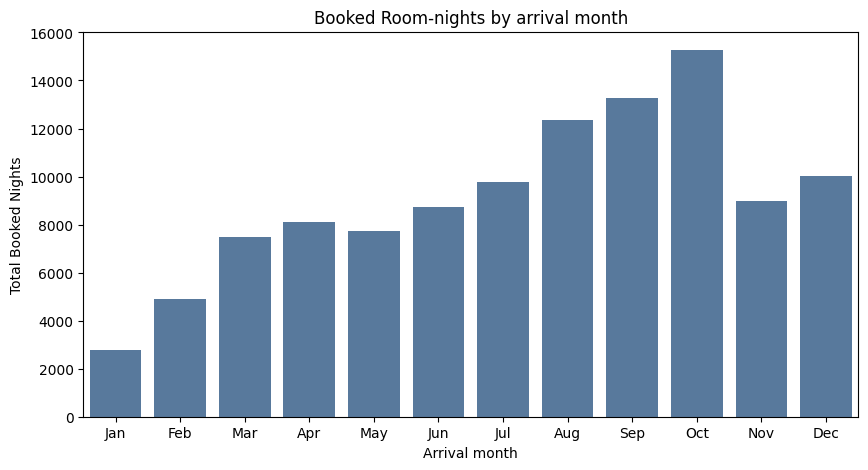

In [15]:
INN_data["total_nights"]=(INN_data["no_of_weekend_nights"]+INN_data["no_of_week_nights"])
monthly_stays=(INN_data.groupby("arrival_month", as_index=False)["total_nights"].sum())
plt.figure(figsize=(10,5))
sns.barplot(data=monthly_stays,
            x="arrival_month",
            y="total_nights",
            color="#4C78A8"
)

plt.title("Booked Room-nights by arrival month")
plt.xlabel("Arrival month")
plt.ylabel("Total Booked Nights")
plt.xticks(
    range(12),
    ["Jan","Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

)
plt.show()

2. Guests by market segment





In [16]:
INN_data.market_segment_type.value_counts()

,count
market_segment_type,
Online,23214
Offline,10528
Corporate,2017
Complementary,391
Aviation,125


We can appreciate that most of the guests come from the Online market segment.

3. Hotel rates are dynamic and change according to demand and customer demographics. What are the differences in room prices in different market segments?

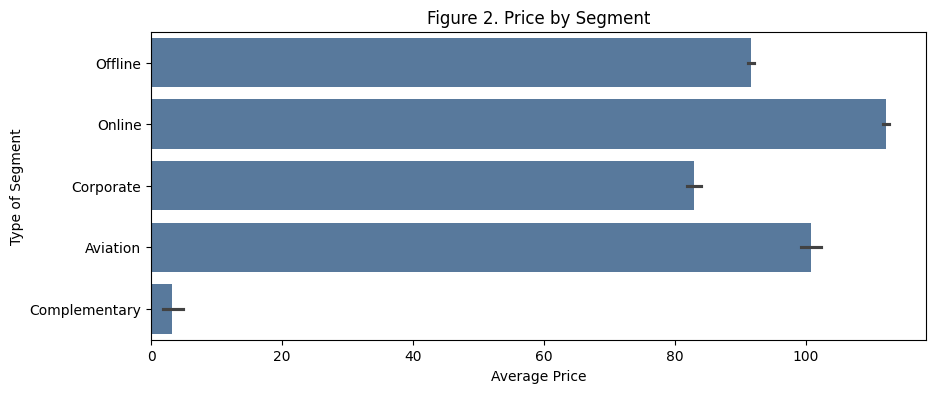

In [17]:
plt.figure(figsize=(10,4))
sns.barplot(data=INN_data, x='avg_price_per_room', y='market_segment_type', color="#4C78A8")
plt.title('Figure 2. Price by Segment')
plt.xlabel('Average Price')
plt.ylabel('Type of Segment')
plt.xticks(rotation=360)
plt.show()

4. Percentage of bookings that are canceled

In [18]:
INN_data.booking_status.value_counts()/INN_data.shape[0]*100

,count
booking_status,
Not_Canceled,67.236389
Canceled,32.763611


We see in the previous table that 32.76% of the reservations are cancelled.

5. Repeating guests are the guests who stay in the hotel often and are important to brand equity. The next section shows the percentage of repeating guests that cancel.

In [19]:
proportions  = pd.crosstab(INN_data['repeated_guest'], INN_data['booking_status'], normalize='index')
print(proportions)

booking_status  Canceled  Not_Canceled
repeated_guest                        
0               0.335804      0.664196
1               0.017204      0.982796


We can see in the previous chart that 1.72% of frequent guests -row labeled 1- cancel the reservation.

6. Many guests have special requirements when booking a hotel room. The next part shows the requirements that affect booking cancellation.

In [20]:
special_request=pd.crosstab(
    INN_data['no_of_special_requests'],
    INN_data['booking_status'],
    normalize='index'
).mul(100)

special_request

booking_status,Canceled,Not_Canceled
no_of_special_requests,,
0,43.206755,56.793245
1,23.766816,76.233184
2,14.596700,85.403300
3,0.000000,100.000000
4,0.000000,100.000000
5,0.000000,100.000000


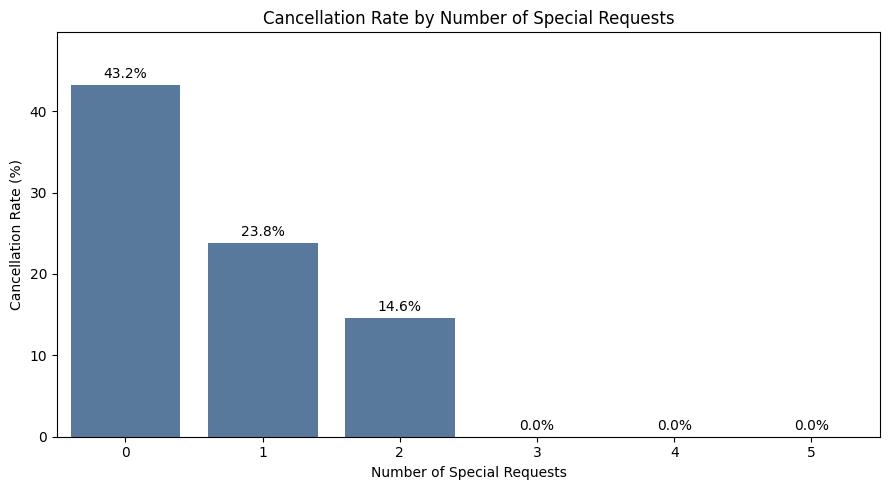

In [21]:
cancellation_by_requests=(
    special_request['Canceled'].rename('cancellation_rate').reset_index())
plt.figure(figsize=(9,5))

ax= sns.barplot(
    data=cancellation_by_requests,
    x="no_of_special_requests",
    y="cancellation_rate",
    color="#4C78A8"
)
plt.title("Cancellation Rate by Number of Special Requests")
plt.xlabel("Number of Special Requests")
plt.ylabel("Cancellation Rate (%)")
plt.ylim(0, cancellation_by_requests["cancellation_rate"].max() * 1.15)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

In [22]:
# Create lead-time groups
lead_time_bins = [-1, 7, 30, 60, 90, 180, float("inf")]

lead_time_labels = [
    "0–7 days",
    "8–30 days",
    "31–60 days",
    "61–90 days",
    "91–180 days",
    "181+ days"
]

INN_data["lead_time_group"] = pd.cut(
    INN_data["lead_time"],
    bins=lead_time_bins,
    labels=lead_time_labels
)

# Summarize each group
lead_time_summary = (
    INN_data.groupby("lead_time_group", observed=False)
        .agg(
            total_bookings=("booking_status", "size"),
            canceled_bookings=(
                "booking_status",
                lambda status: (status == "Canceled").sum()
            )
        )
        .reset_index()
)

lead_time_summary["cancellation_rate"] = (
    lead_time_summary["canceled_bookings"]
    / lead_time_summary["total_bookings"]
    * 100
)

lead_time_summary

,lead_time_group,total_bookings,canceled_bookings,cancellation_rate
0,0–7 days,5801,514,8.860541
1,8–30 days,6610,1249,18.895613
2,31–60 days,6307,1480,23.465990
3,61–90 days,4508,1253,27.795031
4,91–180 days,7772,3490,44.904786
5,181+ days,5277,3899,73.886678


# Naive Bayes Model

In [23]:
data2 = INN_data.copy()

##Prepare data for training

We now from previous exploration that 67.23% are Not_Cancelled reservations and 32.76% are Cancelled. This is a good distribution of cases, roughly 1/3, 2/3.

In [24]:
##change the type of variable to categories
for feature in data2.columns:
    if data2[feature].dtype == 'object':
        data2[feature] = pd.Categorical(data2[feature])# Replace strings with an integer
data2.head(10)

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,...,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_nights,lead_time_group
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,...,2,Offline,0,0,0,65.00,0,Not_Canceled,3,181+ days
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,...,6,Online,0,0,0,106.68,1,Not_Canceled,5,0–7 days
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,...,28,Online,0,0,0,60.00,0,Canceled,3,0–7 days
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,...,20,Online,0,0,0,100.00,0,Canceled,2,181+ days
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,...,11,Online,0,0,0,94.50,0,Canceled,2,31–60 days
5,INN00006,2,0,0,2,Meal Plan 2,0,Room_Type 1,346,2018,...,13,Online,0,0,0,115.00,1,Canceled,2,181+ days
6,INN00007,2,0,1,3,Meal Plan 1,0,Room_Type 1,34,2017,...,15,Online,0,0,0,107.55,1,Not_Canceled,4,31–60 days
7,INN00008,2,0,1,3,Meal Plan 1,0,Room_Type 4,83,2018,...,26,Online,0,0,0,105.61,1,Not_Canceled,4,61–90 days
8,INN00009,3,0,0,4,Meal Plan 1,0,Room_Type 1,121,2018,...,6,Offline,0,0,0,96.90,1,Not_Canceled,4,91–180 days
9,INN00010,2,0,0,5,Meal Plan 1,0,Room_Type 4,44,2018,...,18,Online,0,0,0,133.44,3,Not_Canceled,5,31–60 days


In [25]:
#Prepare the dataset
X = data2.drop(
    columns=[
        "Booking_ID",
        "booking_status",
        "lead_time_group",
        "total_nights"
    ],
    errors="ignore"
)

# Positive class:
# 1 = Canceled
# 0 = Not_Canceled
y = (data2["booking_status"] == "Canceled").astype(int)

print(y.value_counts())
print(y.value_counts(normalize=True))

booking_status
0    24390
1    11885
Name: count, dtype: int64
booking_status
0    0.672364
1    0.327636
Name: proportion, dtype: float64


In [26]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [27]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,  # 25% of 80% = 20% of the complete dataset
    random_state=42,
    stratify=y_train_val
)

print("Training observations:", X_train.shape[0])
print("Validation observations:", X_val.shape[0])
print("Test observations:", X_test.shape[0])

print("\nCancellation rates:")
print("Train:", y_train.mean())
print("Validation:", y_val.mean())
print("Test:", y_test.mean())

Training observations: 21765
Validation observations: 7255
Test observations: 7255

Cancellation rates:
Train: 0.32763611302549966
Validation: 0.32763611302549966
Test: 0.32763611302549966


In [28]:
categorical_features = [
    "type_of_meal_plan",
    "room_type_reserved",
    "market_segment_type"
]

binary_features = [
    "required_car_parking_space",
    "repeated_guest"
]

numeric_features = [
    column for column in X.columns
    if column not in categorical_features + binary_features
]

print("Categorical:", categorical_features)
print("Binary:", binary_features)
print("Numeric:", numeric_features)

Categorical: ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']
Binary: ['required_car_parking_space', 'repeated_guest']
Numeric: ['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests']


In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ],
    remainder="drop"
)

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            KNeighborsClassifier(
                n_neighbors=5,
                weights="distance"
            )
        )
    ]
)

In [31]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

In [32]:
#Compute metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    To compute the performance of a classification model built using sklearn

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [33]:
from sklearn import metrics

In [34]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = metrics.confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

## KNN


In [35]:
knn_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['no_of_adults',
                                                   'no_of_children',
                                                   'no_of_weekend_nights',
                                                   'no_of_week_nights',
                                                   'lead_time', 'arrival_year',
                                                   'arrival_month',
                                                   'arrival_date',
                                                   'no_of_previous_cancellations',
                                                   'no_of_previous_bookings_not_canceled',
                                                   'avg_price_per_room',
                                                   'no_of_special_requests']),
                                                 ('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['type_of_meal_plan',
                                                   'room_type_reserved',
                                                   'market_segment_type']),
                                                 ('binary', 'passthrough',
                                                  ['required_car_parking_space',
                                                   'repeated_guest'])])),
                ('model', KNeighborsClassifier(weights='distance'))])

In [36]:
y_val_pred = knn_pipeline.predict(X_val)

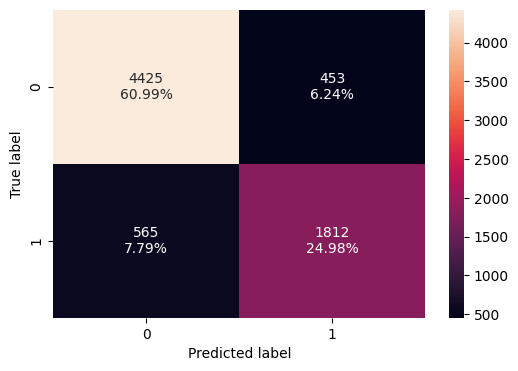

In [37]:
confusion_matrix_sklearn(knn_pipeline, X_val, y_val)

In [38]:
Neighbor = model_performance_classification_sklearn(knn_pipeline, X_train, y_train)
Neighbor

,Accuracy,Recall,Precision,F1
0,0.994716,0.986958,0.996884,0.991896


In [39]:
Neighbor2 = model_performance_classification_sklearn(knn_pipeline, X_val, y_val)
Neighbor2

,Accuracy,Recall,Precision,F1
0,0.859683,0.762305,0.8,0.780698


In [40]:
knn_pipeline2 = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            KNeighborsClassifier(
                n_neighbors=5,
                weights="distance"
            )
        )
    ]
)

In [41]:
knn_pipeline2.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['no_of_adults',
                                                   'no_of_children',
                                                   'no_of_weekend_nights',
                                                   'no_of_week_nights',
                                                   'lead_time', 'arrival_year',
                                                   'arrival_month',
                                                   'arrival_date',
                                                   'no_of_previous_cancellations',
                                                   'no_of_previous_bookings_not_canceled',
                                                   'avg_price_per_room',
                                                   'no_of_special_requests']),
                                                 ('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['type_of_meal_plan',
                                                   'room_type_reserved',
                                                   'market_segment_type']),
                                                 ('binary', 'passthrough',
                                                  ['required_car_parking_space',
                                                   'repeated_guest'])])),
                ('model', KNeighborsClassifier(weights='distance'))])

In [42]:
y_val_pred = knn_pipeline2.predict(X_val)

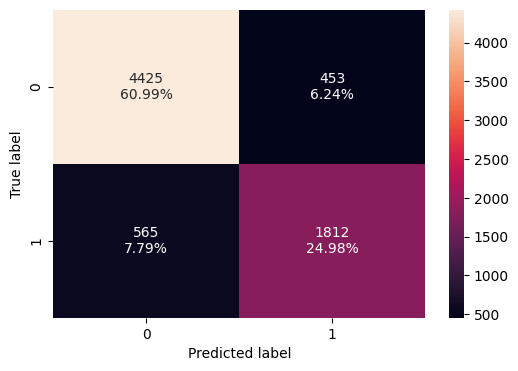

In [43]:
confusion_matrix_sklearn(knn_pipeline2, X_val, y_val)

In [44]:
Neighbor3 = model_performance_classification_sklearn(knn_pipeline2, X_train, y_train)
Neighbor3

,Accuracy,Recall,Precision,F1
0,0.994716,0.986958,0.996884,0.991896


In [45]:
Neighbor4 = model_performance_classification_sklearn(knn_pipeline2, X_val, y_val)
Neighbor4

,Accuracy,Recall,Precision,F1
0,0.859683,0.762305,0.8,0.780698


In [46]:
from sklearn.model_selection import GridSearchCV

In [47]:
KNeighborsClassifier().get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

In [48]:
param_grid = {
    "model__metric": ["minkowski", "manhattan"],
    "model__n_neighbors": [3, 5, 7, 9],
    "model__weights": ["uniform", "distance"]
}

In [49]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="f1",  # Measures the Canceled class because Canceled = 1
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         StandardScaler(),
                                                                         ['no_of_adults',
                                                                          'no_of_children',
                                                                          'no_of_weekend_nights',
                                                                          'no_of_week_nights',
                                                                          'lead_time',
                                                                          'arrival_year',
                                                                          'arrival_month',
                                                                          'arrival_date',
                                                                          'no_of_previous_cancellations',
                                                                          'no_of_pre...
                                                                         ['type_of_meal_plan',
                                                                          'room_type_reserved',
                                                                          'market_segment_type']),
                                                                        ('binary',
                                                                         'passthrough',
                                                                         ['required_car_parking_space',
                                                                          'repeated_guest'])])),
                                       ('model',
                                        KNeighborsClassifier(weights='distance'))]),
             n_jobs=-1,
             param_grid={'model__metric': ['minkowski', 'manhattan'],
                         'model__n_neighbors': [3, 5, 7, 9],
                         'model__weights': ['uniform', 'distance']},
             return_train_score=True, scoring='f1')

In [50]:
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation F1:", grid_search.best_score_)

Best parameters: {'model__metric': 'manhattan', 'model__n_neighbors': 9, 'model__weights': 'distance'}
Best cross-validation F1: 0.7861029734912657


In [51]:
best_knn_pipeline = grid_search.best_estimator_

In [52]:
Neighbor5 = model_performance_classification_sklearn(best_knn_pipeline, X_train, y_train)
Neighbor5

,Accuracy,Recall,Precision,F1
0,0.994716,0.987379,0.996462,0.9919


In [53]:
from sklearn.metrics import classification_report

y_val_pred = best_knn_pipeline.predict(X_val)

print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=["Not Canceled", "Canceled"],
        digits=3
    )
)

              precision    recall  f1-score   support

Not Canceled      0.893     0.918     0.905      4878
    Canceled      0.822     0.774     0.797      2377

    accuracy                          0.871      7255
   macro avg      0.857     0.846     0.851      7255
weighted avg      0.870     0.871     0.870      7255



In [54]:
y_test_pred = best_knn_pipeline.predict(X_test)

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Not Canceled", "Canceled"],
        digits=3
    )
)

              precision    recall  f1-score   support

Not Canceled      0.897     0.915     0.906      4878
    Canceled      0.819     0.785     0.802      2377

    accuracy                          0.873      7255
   macro avg      0.858     0.850     0.854      7255
weighted avg      0.872     0.873     0.872      7255



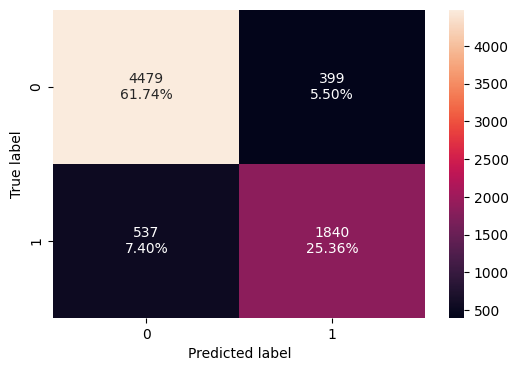

In [55]:
confusion_matrix_sklearn(best_knn_pipeline, X_val, y_val)

In [77]:
from sklearn.inspection import permutation_importance
import pandas as pd

# Use validation data for model interpretation
# rather than repeatedly inspecting the final test set
sample_size = min(1000, len(X_val))

X_importance = X_val.sample(
    n=sample_size,
    random_state=42
)

# Select the corresponding target rows
y_importance = y_val.loc[X_importance.index]

result = permutation_importance(
    estimator=best_knn_pipeline,
    X=X_importance,
    y=y_importance,
    scoring="f1",      # Importance for cancellation F1
    n_repeats=3,
    random_state=42,
    n_jobs=1           # Helps prevent memory overload
)

feature_importances = pd.DataFrame({
    "feature": X_importance.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values(
    "importance_mean",
    ascending=False
)

feature_importances.head(10)

,feature,importance_mean,importance_std
7,lead_time,0.177172,0.006880
16,no_of_special_requests,0.150217,0.016484
11,market_segment_type,0.102760,0.004871
15,avg_price_per_room,0.060420,0.009698
9,arrival_month,0.057192,0.005809
2,no_of_weekend_nights,0.044204,0.017235
0,no_of_adults,0.043074,0.009092
10,arrival_date,0.042042,0.007855
8,arrival_year,0.038162,0.006099
3,no_of_week_nights,0.035495,0.003166


##Support Vector Machine


In [56]:
from sklearn import svm

In [57]:
svm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            svm.SVC(gamma=0.025, C=3)
        )
    ]
)

In [58]:
svm_pipeline.fit(X_train , y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['no_of_adults',
                                                   'no_of_children',
                                                   'no_of_weekend_nights',
                                                   'no_of_week_nights',
                                                   'lead_time', 'arrival_year',
                                                   'arrival_month',
                                                   'arrival_date',
                                                   'no_of_previous_cancellations',
                                                   'no_of_previous_bookings_not_canceled',
                                                   'avg_price_per_room',
                                                   'no_of_special_requests']),
                                                 ('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['type_of_meal_plan',
                                                   'room_type_reserved',
                                                   'market_segment_type']),
                                                 ('binary', 'passthrough',
                                                  ['required_car_parking_space',
                                                   'repeated_guest'])])),
                ('model', SVC(C=3, gamma=0.025))])

In [59]:
y_val_pred_1 = svm_pipeline.predict(X_val)

In [60]:
y_train_pred_1=svm_pipeline.predict(X_train)

In [61]:
print(
    classification_report(
        y_train,
        y_train_pred_1,
        target_names=["Not Canceled", "Canceled"],
        digits=3
    )
)

              precision    recall  f1-score   support

Not Canceled      0.847     0.928     0.885     14634
    Canceled      0.815     0.655     0.727      7131

    accuracy                          0.838     21765
   macro avg      0.831     0.791     0.806     21765
weighted avg      0.836     0.838     0.833     21765



In [62]:
print(
    classification_report(
        y_val,
        y_val_pred_1,
        target_names=["Not Canceled", "Canceled"],
        digits=3
    )
)

              precision    recall  f1-score   support

Not Canceled      0.845     0.928     0.884      4878
    Canceled      0.814     0.650     0.723      2377

    accuracy                          0.837      7255
   macro avg      0.830     0.789     0.804      7255
weighted avg      0.835     0.837     0.831      7255



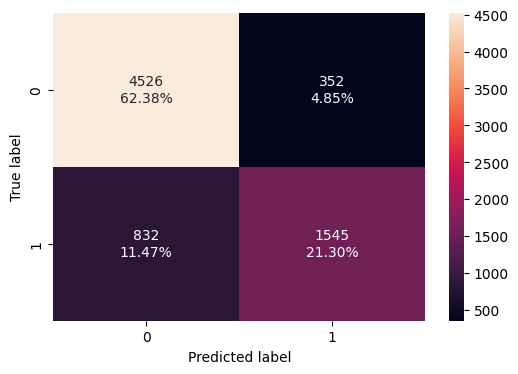

In [63]:
confusion_matrix_sklearn(svm_pipeline, X_val, y_val)

In [64]:
svm.SVC().get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [65]:
grid_parameters = [
    # Linear SVM: gamma is not used
    {
        "model__kernel": ["linear"],
        "model__C": [0.5, 1, 1.5, 2]
    },

    # RBF SVM: both C and gamma are used
    {
        "model__kernel": ["rbf"],
        "model__C": [0.5, 1, 1.5, 2],
        "model__gamma": [0.05, 0.075, 0.095, 0.1]
    }
]

In [66]:
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search2 = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=grid_parameters,
    cv=cv_strategy,
    scoring="f1",
    n_jobs=-1,
    return_train_score=True
)

grid_search2.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         StandardScaler(),
                                                                         ['no_of_adults',
                                                                          'no_of_children',
                                                                          'no_of_weekend_nights',
                                                                          'no_of_week_nights',
                                                                          'lead_time',
                                                                          'arrival_year',
                                                                          'arrival_month',
                                                                          'arrival_date',
                                                                          'no_of_previous_cancellations',
                                                                          'no_of_pre...
                                                                          'room_type_reserved',
                                                                          'market_segment_type']),
                                                                        ('binary',
                                                                         'passthrough',
                                                                         ['required_car_parking_space',
                                                                          'repeated_guest'])])),
                                       ('model', SVC(C=3, gamma=0.025))]),
             n_jobs=-1,
             param_grid=[{'model__C': [0.5, 1, 1.5, 2],
                          'model__kernel': ['linear']},
                         {'model__C': [0.5, 1, 1.5, 2],
                          'model__gamma': [0.05, 0.075, 0.095, 0.1],
                          'model__kernel': ['rbf']}],
             return_train_score=True, scoring='f1')

In [67]:
print("Best parameters:", grid_search2.best_params_)
print("Best cross-validation F1:", grid_search2.best_score_)

Best parameters: {'model__C': 2, 'model__gamma': 0.1, 'model__kernel': 'rbf'}
Best cross-validation F1: 0.7547389782135443


In [68]:
best_svm_pipeline = grid_search2.best_estimator_

In [69]:
from sklearn.metrics import classification_report

y_train_pred_svm = best_svm_pipeline.predict(X_train)

print(
    classification_report(
        y_train,
        y_train_pred_svm,
        target_names=["Not Canceled", "Canceled"],
        digits=3
    )
)

              precision    recall  f1-score   support

Not Canceled      0.879     0.929     0.903     14634
    Canceled      0.834     0.738     0.784      7131

    accuracy                          0.866     21765
   macro avg      0.857     0.834     0.843     21765
weighted avg      0.865     0.866     0.864     21765



In [70]:
from sklearn.metrics import classification_report

y_val_pred_svm = best_svm_pipeline.predict(X_val)

print(
    classification_report(
        y_val,
        y_val_pred_svm,
        target_names=["Not Canceled", "Canceled"],
        digits=3
    )
)

              precision    recall  f1-score   support

Not Canceled      0.874     0.920     0.896      4878
    Canceled      0.816     0.727     0.769      2377

    accuracy                          0.857      7255
   macro avg      0.845     0.824     0.833      7255
weighted avg      0.855     0.857     0.855      7255



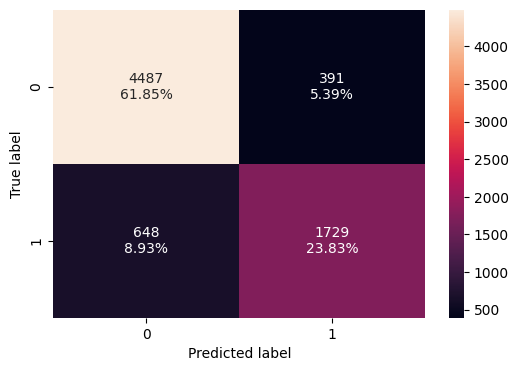

In [71]:
confusion_matrix_sklearn(best_svm_pipeline, X_val, y_val)

In [72]:
from sklearn.metrics import classification_report

y_test_pred_svm = best_svm_pipeline.predict(X_test)

print(
    classification_report(
        y_test,
        y_test_pred_svm,
        target_names=["Not Canceled", "Canceled"],
        digits=3
    )
)

              precision    recall  f1-score   support

Not Canceled      0.876     0.919     0.897      4878
    Canceled      0.816     0.734     0.773      2377

    accuracy                          0.859      7255
   macro avg      0.846     0.827     0.835      7255
weighted avg      0.857     0.859     0.857      7255



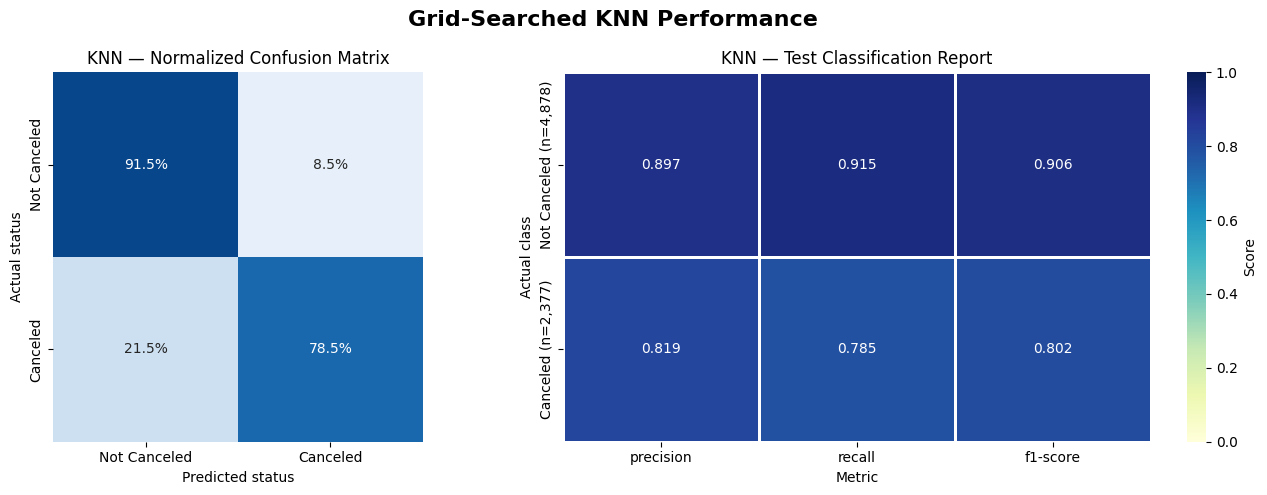

In [75]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class_names = ["Not Canceled", "Canceled"]

# Use the test set only after model selection is finished
y_test_pred_knn = best_knn_pipeline.predict(X_test)

# Normalized confusion matrix
knn_cm = confusion_matrix(
    y_test,
    y_test_pred_knn,
    labels=[0, 1],
    normalize="true"
)

# Classification report as a DataFrame for plotting
knn_report = classification_report(
    y_test,
    y_test_pred_knn,
    labels=[0, 1],
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

knn_report_df = (
    pd.DataFrame(knn_report)
      .T
      .loc[class_names, ["precision", "recall", "f1-score", "support"]]
)

knn_support = knn_report_df["support"].astype(int)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    gridspec_kw={"width_ratios": [1, 1.25]}
)

# Confusion matrix
sns.heatmap(
    knn_cm,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    vmin=0,
    vmax=1,
    square=True,
    cbar=False,
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0]
)

axes[0].set_title("KNN — Normalized Confusion Matrix")
axes[0].set_xlabel("Predicted status")
axes[0].set_ylabel("Actual status")

# Classification-report heatmap
sns.heatmap(
    knn_report_df[["precision", "recall", "f1-score"]],
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=1,
    cbar_kws={"label": "Score"},
    yticklabels=[
        f"Not Canceled (n={knn_support['Not Canceled']:,})",
        f"Canceled (n={knn_support['Canceled']:,})"
    ],
    ax=axes[1]
)

axes[1].set_title("KNN — Test Classification Report")
axes[1].set_xlabel("Metric")
axes[1].set_ylabel("Actual class")

fig.suptitle(
    "Grid-Searched KNN Performance",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

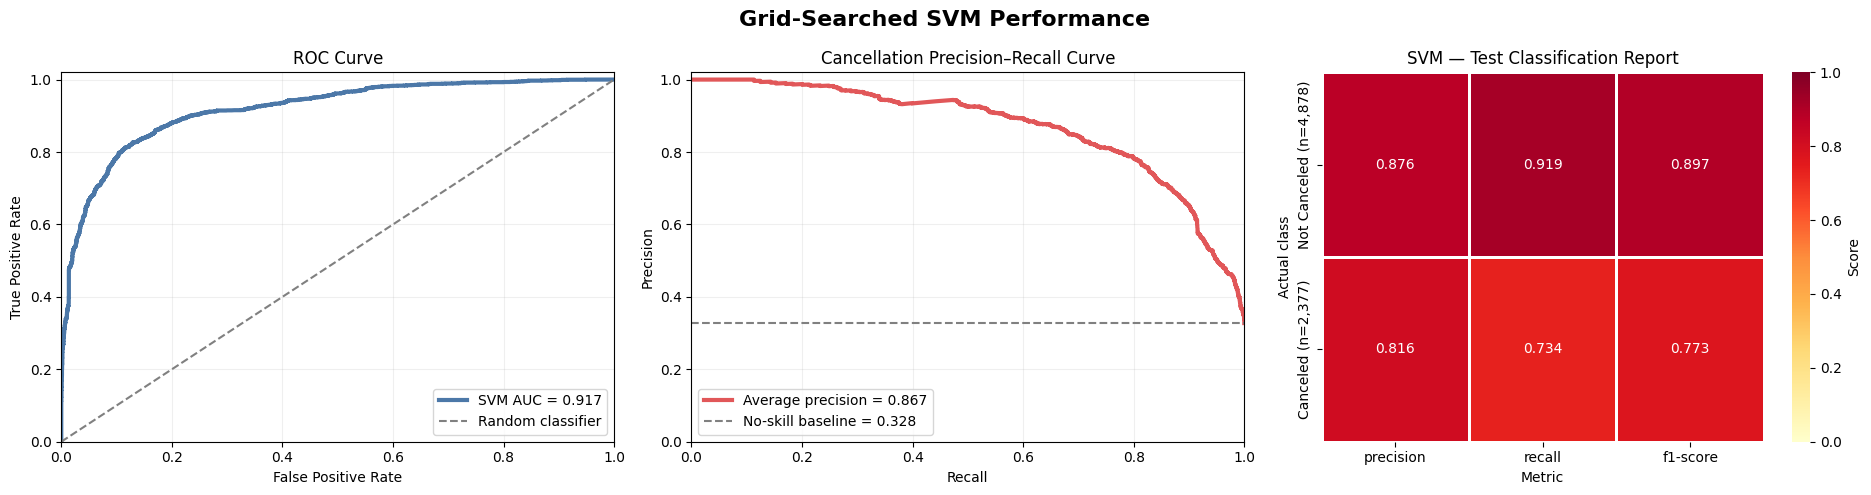

In [76]:
from sklearn.metrics import (
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

# Actual predictions from the tuned SVM
y_test_pred_svm = best_svm_pipeline.predict(X_test)

# Continuous SVM decision scores
y_test_score_svm = best_svm_pipeline.decision_function(X_test)

# ROC values
fpr, tpr, _ = roc_curve(y_test, y_test_score_svm)
roc_auc = roc_auc_score(y_test, y_test_score_svm)

# Precision-recall values
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_test_score_svm
)

average_precision = average_precision_score(
    y_test,
    y_test_score_svm
)

# Visual classification report
svm_report = classification_report(
    y_test,
    y_test_pred_svm,
    labels=[0, 1],
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

svm_report_df = (
    pd.DataFrame(svm_report)
      .T
      .loc[class_names, ["precision", "recall", "f1-score", "support"]]
)

svm_support = svm_report_df["support"].astype(int)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# ROC curve
axes[0].plot(
    fpr,
    tpr,
    color="#4C78A8",
    linewidth=3,
    label=f"SVM AUC = {roc_auc:.3f}"
)

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random classifier"
)

axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.02)
axes[0].grid(alpha=0.2)
axes[0].legend(loc="lower right")

# Precision-recall curve
axes[1].plot(
    recall_curve,
    precision_curve,
    color="#E15759",
    linewidth=3,
    label=f"Average precision = {average_precision:.3f}"
)

# No-skill baseline equals the cancellation prevalence
baseline = y_test.mean()

axes[1].axhline(
    baseline,
    linestyle="--",
    color="gray",
    label=f"No-skill baseline = {baseline:.3f}"
)

axes[1].set_title("Cancellation Precision–Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.02)
axes[1].grid(alpha=0.2)
axes[1].legend(loc="lower left")

# Classification-report heatmap
sns.heatmap(
    svm_report_df[["precision", "recall", "f1-score"]],
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    linewidths=1,
    cbar_kws={"label": "Score"},
    yticklabels=[
        f"Not Canceled (n={svm_support['Not Canceled']:,})",
        f"Canceled (n={svm_support['Canceled']:,})"
    ],
    ax=axes[2]
)

axes[2].set_title("SVM — Test Classification Report")
axes[2].set_xlabel("Metric")
axes[2].set_ylabel("Actual class")

fig.suptitle(
    "Grid-Searched SVM Performance",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()